      Apellido  Salario
0         King  24000.0
1      Kochhar  17000.0
2      De Haan  17000.0
3       Hunold   9000.0
4    Greenberg  12000.0
5       Faviet   9000.0
6         Chen   8200.0
7     Raphaely  11000.0
8        Fripp   8200.0
9      Russell  14000.0
10    Partners  13500.0
11      Taylor   8600.0
12  Livingston   8400.0
13   Hartstein  13000.0
14        Baer  10000.0
15     Higgins  12000.0
16       Gietz   8300.0


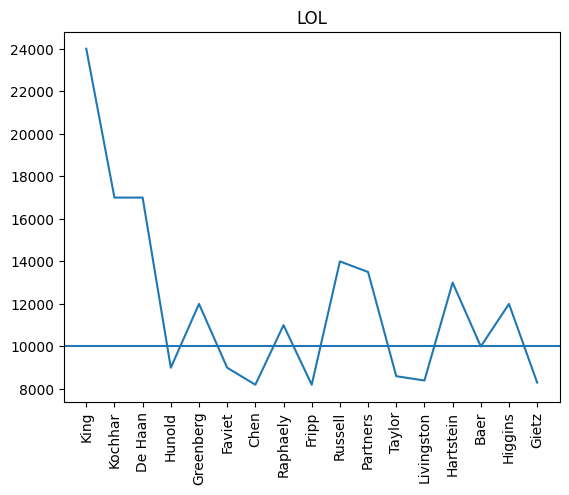

In [ ]:
import oracledb
import matplotlib.pyplot as plt
import pandas as pd

try:
    conn = oracledb.connect(
        user="hr",
        password="basededatos",
        dsn="localhost:1521/xe"
    )
except oracledb.Error as e:
    print(e)

cursor = conn.cursor()

# EJERCICIO 1: Salarios mayores al promedio (con gráfico)
cursor.execute("SELECT last_name, salary FROM employees WHERE salary > (SELECT AVG(salary) FROM employees)")
datos = cursor.fetchall()
columnas = ['Apellido', 'Salario']
df = pd.DataFrame(datos, columns=columnas)
print(df)
plt.Figure(figsize=(10,6))
plt.title('LOL')
#BARRAS

#plt.bar(df["Apellido"], df["Salario"])
# plt.xlabel('Apellidos')
# plt.ylabel('Salario')
# plt.xticks(rotation=90)

#PIE
# plt.pie(df.Salario, labels = df.Apellido, autopct='%1.1f%%')

#LINEPLOT
plt.plot(df.Apellido, df.Salario)
plt.xticks(rotation=90)

plt.axhline(10000)
plt.show()

     Region  Numero_de_empleados
0  Americas                   32
1    Europe                    8


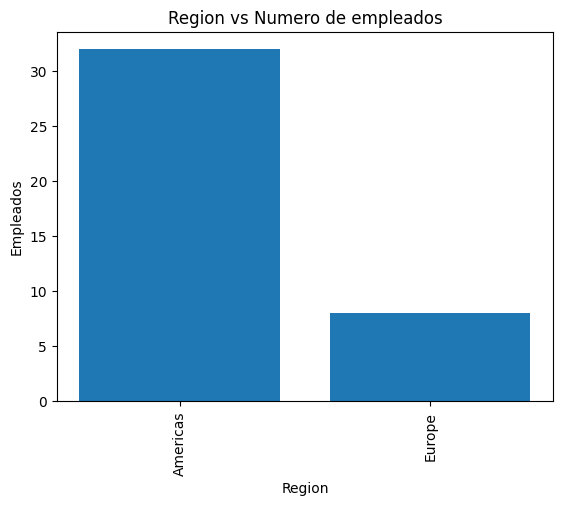

In [1]:
import oracledb
import pandas as pd
import matplotlib.pyplot as plt

try:
    conn = oracledb.connect(
        user = 'hr',
        password = 'basededatos',
        dsn = 'localhost:1521/XE'
    )
except oracledb.Error as e:
    print(e)

cursor = conn.cursor()

cursor.execute(
"""
SELECT r.region_name, COUNT(employee_id) AS "Numero de Empleados" FROM employees e
JOIN departments d ON e.department_id = d.department_id
JOIN locations l ON d.location_id = l.location_id
JOIN countries c ON l.country_id = c.country_id
JOIN regions r ON c.region_id = r.region_id
GROUP BY (r.region_name)
"""
)

resultados = cursor.fetchall()
columnas = ['Region', 'Numero_de_empleados']

df = pd.DataFrame(resultados, columns=columnas)
print(df)

plt.Figure(figsize=(10,6))
plt.title('Region vs Numero de empleados')
#Barras
plt.bar(df.Region, df.Numero_de_empleados)
plt.xlabel('Region')
plt.ylabel('Empleados')
plt.xticks(rotation=90)
plt.show()

#Pastel
#plt.pie(df.Numero_de_empleados, labels=df.Region, autopct='%1.1f%%')
#plt.show()
